# Seasonal Agriculture Performance Analysis

**Name:** Ravi Kumar  
STU ID:STU6a6438c1bf14a1784953025
## Aim
In this project, I have analyzed an agriculture dataset to understand crop yield, profit, irrigation, water usage and seasonal performance.

## 1. Problem Statement

Agriculture depends on many factors such as crop, season, rainfall, irrigation, cost and market price.

The purpose of this project is to use the given dataset and find useful patterns related to **profit, yield and water efficiency**.

## 2. Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Upload CSV file
from google.colab import files

uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(file_name)

print("Dataset loaded successfully")
print("Rows and columns:", df.shape)

df.head()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Dataset loaded successfully
Rows and columns: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Checking the Dataset

First, I checked the number of rows, columns and missing values.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 4000
Number of columns: 28

Missing values:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Wate

## 4. Data Cleaning

There are some missing values in rainfall, soil moisture and yield.

I used the **median** of each column to fill these missing values.

In [5]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())
df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].median())

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


# 5. Data Visualization

I selected seven charts to understand the main patterns in the agriculture data.

## Chart 1: Average Profit by Crop

This chart compares the average profit of different crops.

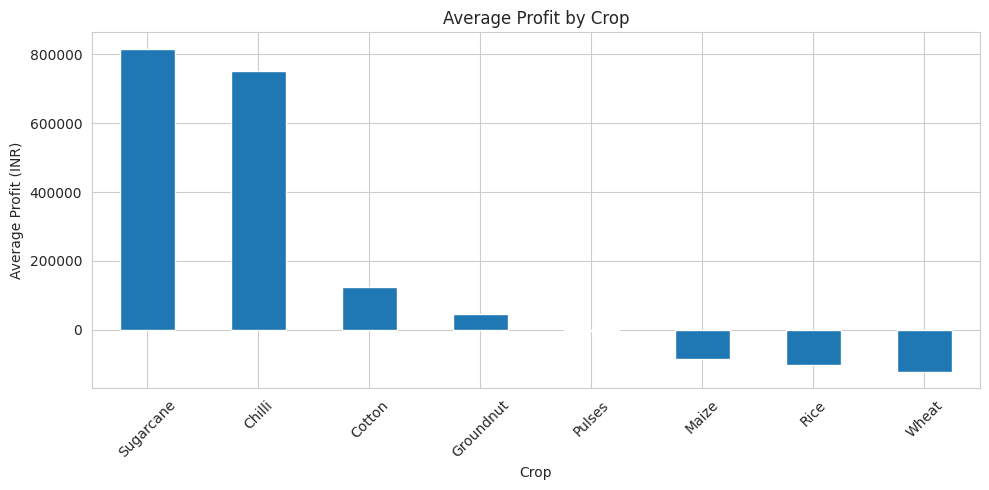

In [6]:
profit_crop = df.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
profit_crop.plot(kind="bar")
plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

From the chart, **Sugarcane and Chilli** have the highest average profit. Some crops have negative average profit.

So, profit is quite different from one crop to another.

## Chart 2: Average Yield by Irrigation Method

Here I compared the average yield for different irrigation methods.

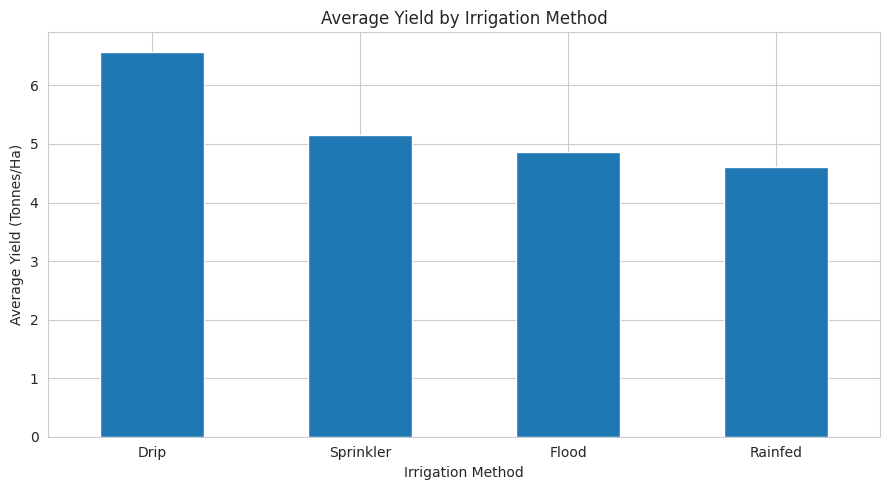

In [7]:
yield_irrigation = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
yield_irrigation.plot(kind="bar")
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

Drip irrigation has the highest average yield in this dataset. Rainfed farms have the lowest average yield among the four methods.

This is an observation from the dataset and does not prove that irrigation method alone causes the difference.

## Chart 3: Average Profit by Season

This chart shows how average profit changes across Kharif, Rabi and Zaid seasons.

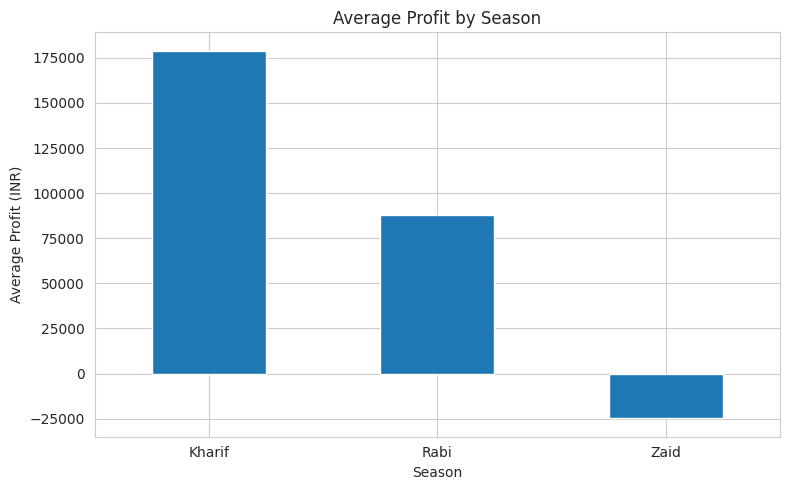

In [8]:
profit_season = df.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
profit_season.plot(kind="bar")
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

Kharif has the highest average profit. Rabi is lower, while Zaid has negative average profit in this dataset.

## Chart 4: Average Profit by State

I used a horizontal bar chart to compare the average profit of different states.

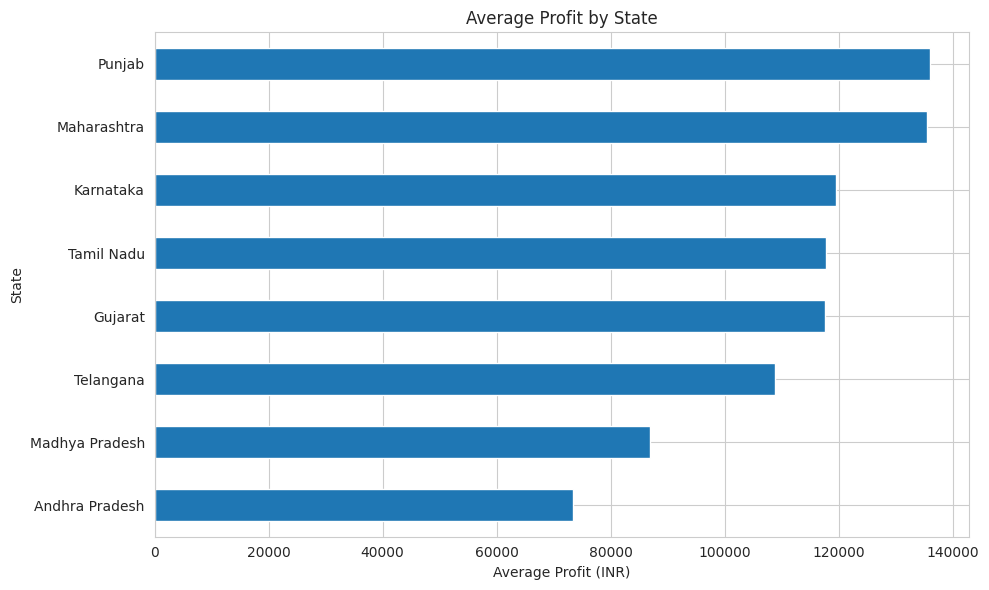

In [9]:
profit_state = df.groupby("State")["Profit_INR"].mean().sort_values()

plt.figure(figsize=(10,6))
profit_state.plot(kind="barh")
plt.title("Average Profit by State")
plt.xlabel("Average Profit (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### Observation

Punjab and Maharashtra have the highest average profit in the dataset. Andhra Pradesh has the lowest average profit among the states shown.

## Chart 5: Water Used vs Yield

This scatter plot helps to see the relationship between water used and crop yield.

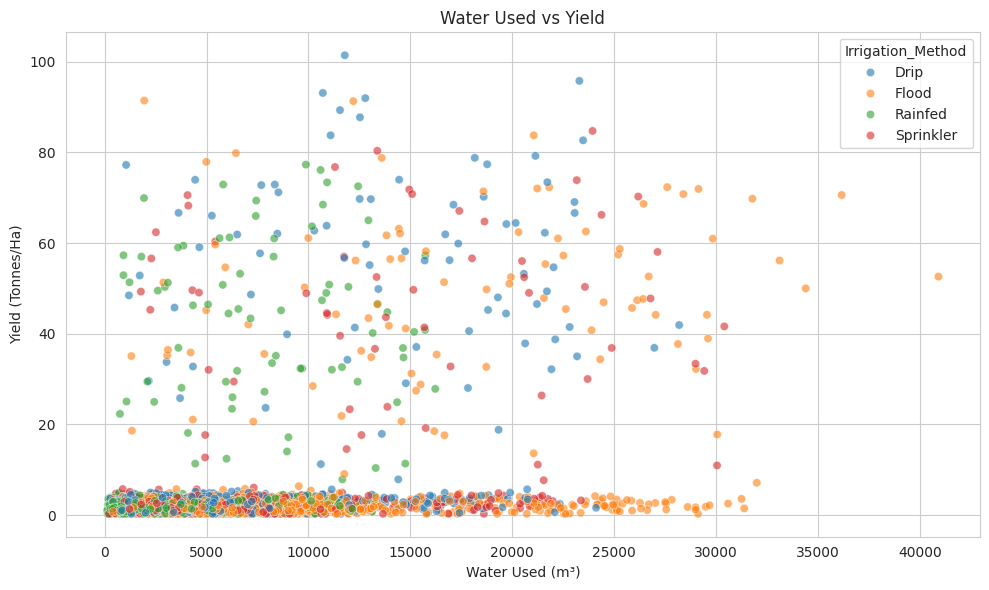

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Irrigation_Method",
    alpha=0.6
)

plt.title("Water Used vs Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

### Observation

The points are spread across different water-use and yield levels. The irrigation groups also show different patterns.

Water efficiency is more strongly related to yield than total water used alone in this dataset.

## Chart 6: Average Water Efficiency by Crop

Here I compared water efficiency between different crops.

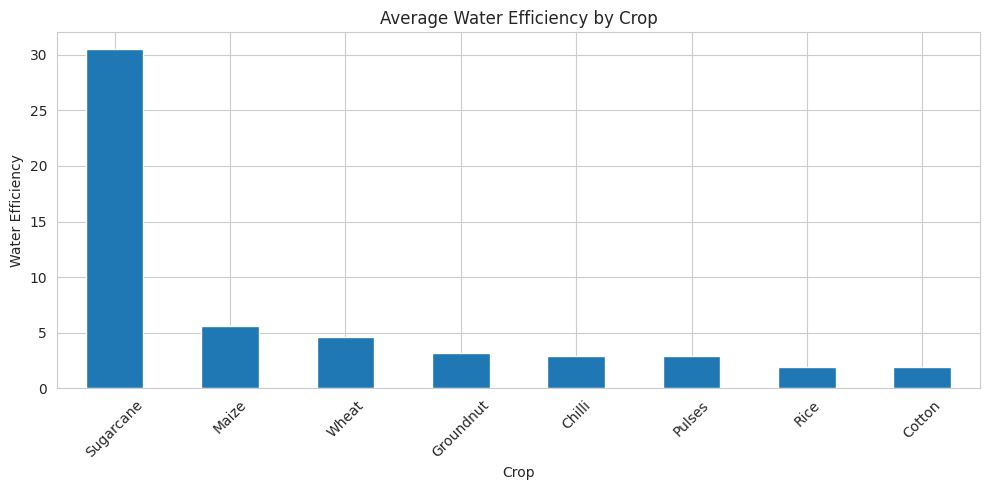

In [11]:
water_efficiency = df.groupby("Crop")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
water_efficiency.plot(kind="bar")
plt.title("Average Water Efficiency by Crop")
plt.xlabel("Crop")
plt.ylabel("Water Efficiency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Sugarcane has a much higher average water-efficiency value than the other crops. Maize also has relatively high water efficiency.

Sugarcane is quite different from the other crops, so this value should be considered as an outlier when comparing crops.

## Chart 7: Correlation Heatmap

The heatmap shows the relationship between numerical columns in the dataset.

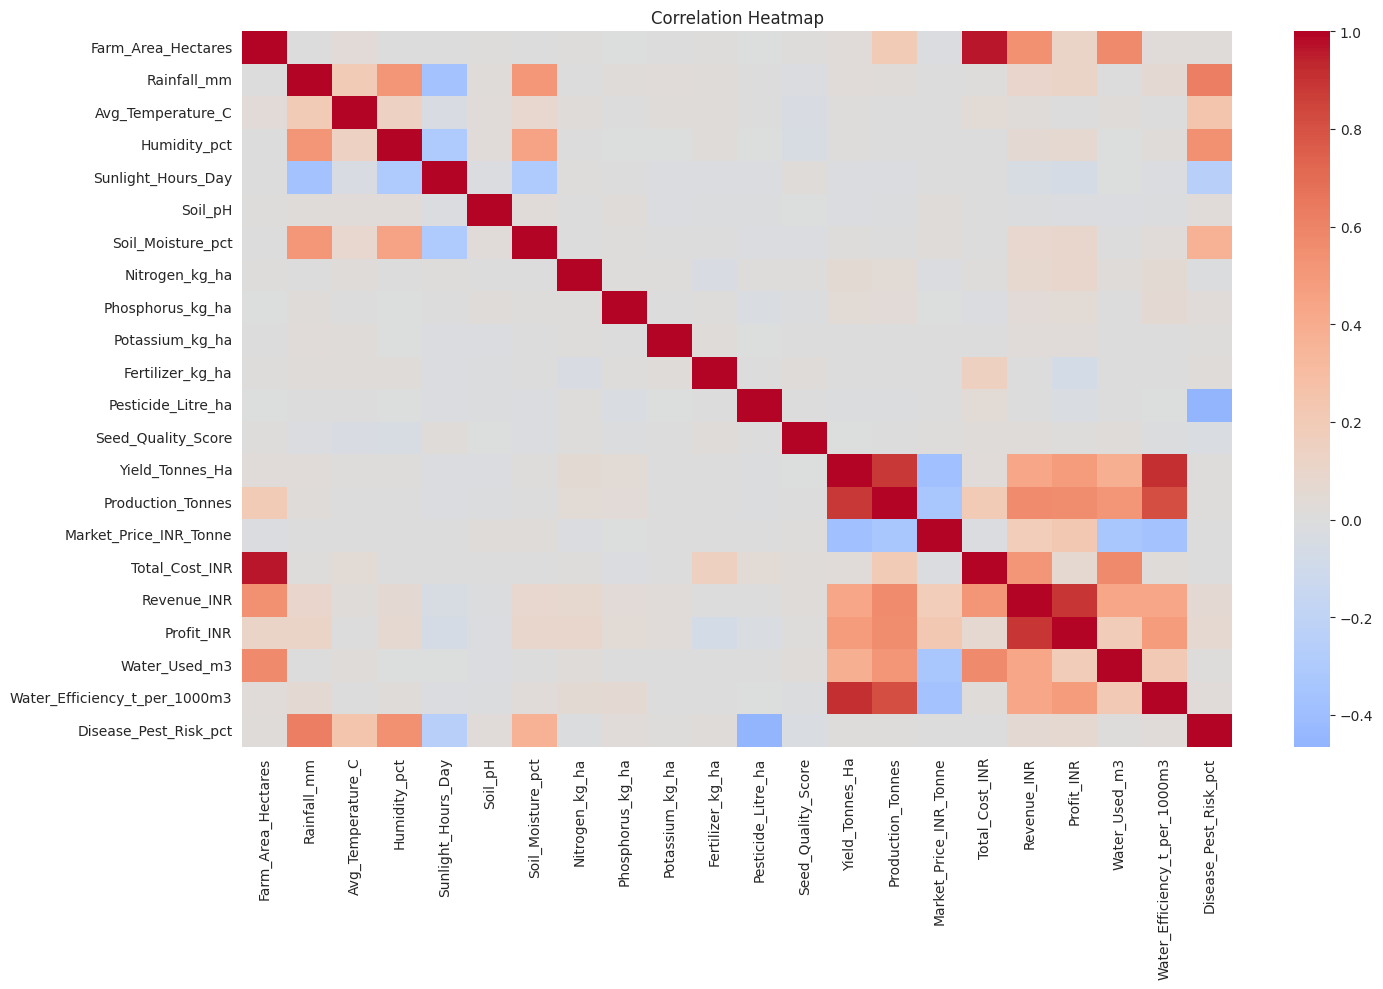

In [12]:
numeric_data = df.select_dtypes(include=np.number)

plt.figure(figsize=(15,10))
sns.heatmap(numeric_data.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation

Some important relationships visible in the heatmap are:

- Revenue has a strong positive relationship with Profit.
- Production and Yield have a strong relationship.
- Water Efficiency has a very strong positive relationship with Yield.
- Some other variables have weaker relationships.

Correlation only shows a relationship between variables; it does not prove cause and effect.

# 6. Main Findings

After analyzing all seven charts, I found the following points:

1. Sugarcane and Chilli have the highest average profit.
2. Drip irrigation has the highest average yield.
3. Kharif has the highest average profit among the three seasons.
4. Punjab and Maharashtra have the highest average state-level profit.
5. Water efficiency has a strong relationship with yield.
6. Sugarcane has unusually high yield and water-efficiency values compared with other crops.
7. Profitability is different across crops, seasons and states.

# 7. Conclusion

In this project, I used Python, Pandas, Matplotlib and Seaborn to analyze agricultural data.

The analysis helped me understand how **crop, irrigation method, season and state** are related to profit and yield.

The most important finding is that agricultural performance is not the same for every crop or region. Water efficiency and yield also show a strong relationship in the dataset.

This project can be extended in the future using machine learning to predict crop yield or profit.

# 8. Future Scope

In the future, this project can be improved by:

- Predicting crop yield using Machine Learning
- Predicting farm profit
- Recommending suitable crops
- Recommending irrigation methods
- Adding real-time weather data
- Creating an interactive dashboard using Power BI or Tableau

# 9. Tools Used

**Python | Pandas | NumPy | Matplotlib | Seaborn | Google Colab**

**Project Type:** Exploratory Data Analysis and Data Visualization